## Flight data

<a href="#PCA" style="text-decoration: none;">
    <button style="padding:10px; font-size:15px;">PCA</button>
</a>

<a href="#PC" style="text-decoration: none;">
    <button style="padding:10px; font-size:15px;">PCA Components</button>
</a>

<a href="#Clusters" style="text-decoration: none;">
    <button style="padding:10px; font-size:15px;">Clusters</button>
</a>

<a href="#Cluster-Visual" style="text-decoration: none;">
    <button style="padding:10px; font-size:15px;">Cluster Visual</button>
</a>

<a href="#Time-Series" style="text-decoration: none;">
    <button style="padding:10px; font-size:15px;">Time Series</button>
</a>

## Data Prep

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
final = pd.read_csv('final_full.csv').drop('Unnamed: 0',axis=1)

In [4]:
final

,EWRcx,EWRcount,EWRCX_rate,EWRarr_delay,EWRdep_delay,EWRair_delay,ZFWcx,ZFWcount,ZFWCX_rate,ZFWarr_delay,...,JFKCX_rate,JFKarr_delay,JFKdep_delay,JFKair_delay,LGAcx,LGAcount,LGACX_rate,LGAarr_delay,LGAdep_delay,LGAair_delay
0,4.0,341.0,0.011594,558.155425,710.900293,4.900293,43.0,972.0,0.042365,579.823045,...,0.007326,917.907749,1079.841328,5.571956,15.0,237.0,0.059524,455.312236,662.746835,4.181435
1,27.0,362.0,0.069409,3084.149171,2736.348066,2.497238,51.0,960.0,0.050445,922.043750,...,0.066901,2468.366038,1975.200000,7.332075,13.0,225.0,0.054622,1420.693333,1545.897778,3.244444
2,56.0,384.0,0.127273,4232.177083,3473.752604,2.221354,50.0,1079.0,0.044287,1062.615385,...,0.151899,3614.070896,3032.014925,3.634328,51.0,308.0,0.142061,3461.574675,2994.766234,4.457792
3,50.0,412.0,0.108225,1658.417476,1473.237864,4.024272,51.0,1123.0,0.043441,855.781834,...,0.097315,1274.732342,1172.118959,4.646840,11.0,353.0,0.030220,742.005666,738.994334,3.818697
4,12.0,403.0,0.028916,1097.935484,947.141439,2.682382,30.0,1117.0,0.026155,548.689346,...,0.000000,466.717842,314.431535,4.248963,12.0,363.0,0.032000,467.592287,441.903581,4.341598
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4864,5.0,375.0,0.013158,1533.669333,1495.680000,2.917333,7.0,1266.0,0.005499,955.827014,...,0.007326,706.073801,676.605166,4.154982,5.0,255.0,0.019231,689.482353,749.411765,2.050980
4865,20.0,393.0,0.048426,3150.793893,3186.106870,2.735369,13.0,1345.0,0.009573,1174.373978,...,0.003472,589.710801,714.146341,3.118467,0.0,351.0,0.000000,885.324786,828.376068,3.566952
4866,8.0,402.0,0.019512,2401.731343,2427.313433,2.564677,16.0,1346.0,0.011747,985.710253,...,0.013889,1303.151408,1408.309859,4.288732,3.0,383.0,0.007772,1258.590078,1197.650131,3.861619
4867,55.0,375.0,0.127907,2771.992000,2572.320000,3.778667,29.0,1314.0,0.021593,1110.789954,...,0.010526,2416.957447,2041.276596,8.471631,9.0,376.0,0.023377,1684.968085,1325.904255,3.242021


In [7]:
cx = pd.read_csv('CANCELL_34_DEP.csv').drop('Unnamed: 0',axis=1)
cx

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,201001,1,3.0,13.0,24.0,5.0,8.0,19.0,1.0,27.0,...,13.0,16.0,8.0,3.0,9.0,3.0,5.0,1.0,3.0,9.0
1,201001,2,13.0,26.0,15.0,20.0,5.0,36.0,6.0,20.0,...,19.0,10.0,10.0,3.0,12.0,2.0,9.0,2.0,10.0,8.0
2,201001,3,42.0,10.0,15.0,17.0,3.0,66.0,4.0,22.0,...,19.0,9.0,12.0,7.0,13.0,1.0,7.0,2.0,20.0,26.0
3,201001,4,12.0,21.0,9.0,20.0,7.0,29.0,9.0,7.0,...,17.0,11.0,9.0,6.0,18.0,2.0,9.0,2.0,7.0,7.0
4,201001,5,5.0,12.0,3.0,13.0,3.0,9.0,4.0,6.0,...,22.0,7.0,9.0,1.0,9.0,5.0,2.0,5.0,0.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4864,202407,27,2.0,1.0,1.0,0.0,3.0,1.0,3.0,2.0,...,3.0,0.0,4.0,0.0,1.0,1.0,2.0,0.0,0.0,1.0
4865,202407,28,9.0,2.0,10.0,1.0,2.0,2.0,4.0,1.0,...,1.0,2.0,6.0,0.0,1.0,2.0,0.0,5.0,0.0,1.0
4866,202407,29,2.0,3.0,6.0,0.0,2.0,3.0,2.0,1.0,...,3.0,3.0,1.0,2.0,6.0,2.0,1.0,2.0,0.0,1.0
4867,202407,30,23.0,8.0,4.0,2.0,3.0,12.0,6.0,3.0,...,9.0,6.0,1.0,4.0,3.0,0.0,3.0,0.0,0.0,5.0


In [15]:
dep = pd.read_csv('final_DEP.csv').drop('Unnamed: 0',axis=1)
dep

,0,1,2,3,4,5,6,7,8,9,...,129,130,131,132,133,134,135,136,137,138
0,201001,1,6,348.0,663.936782,774.925287,2.301724,986.0,672.471602,678.249493,...,564.080268,0.561873,273.0,1160.175824,1267.186813,2.113553,234.0,435.846154,522.764957,2.316239
1,201001,2,7,363.0,1995.545455,2232.203857,2.606061,953.0,979.572928,1044.833158,...,268.903654,0.720930,267.0,2429.558052,2596.790262,2.104869,226.0,738.557522,1024.650442,2.247788
2,201001,3,1,365.0,3172.460274,3715.221918,2.128767,1091.0,1122.727773,1120.966086,...,522.614841,1.515901,271.0,4058.136531,3908.634686,1.904059,304.0,2019.720395,2531.230263,1.950658
3,201001,4,2,432.0,1302.935185,1968.143519,2.020833,1123.0,964.936776,930.728406,...,633.333333,1.376344,266.0,864.364662,1342.327068,1.289474,352.0,415.593750,585.286932,2.125000
4,201001,5,3,402.0,697.124378,1233.266169,2.470149,1119.0,631.983021,642.403038,...,450.537879,0.848485,240.0,293.137500,646.658333,1.570833,364.0,204.994505,330.052198,2.425824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4864,202407,27,7,377.0,806.307692,905.729443,2.657825,1268.0,968.760252,1034.290221,...,564.461538,1.115385,271.0,405.321033,476.457565,2.601476,258.0,505.116279,598.604651,2.627907
4865,202407,28,1,390.0,1650.658974,1977.384615,2.830769,1344.0,1365.915179,1398.392857,...,335.510204,0.974490,286.0,642.972028,645.944056,3.524476,345.0,588.144928,718.434783,3.501449
4866,202407,29,2,406.0,1433.963054,1612.167488,2.352217,1343.0,1009.560685,1038.540581,...,402.096447,0.931472,286.0,1068.244755,1063.006993,3.493007,383.0,722.250653,911.906005,3.812010
4867,202407,30,3,375.0,1881.165333,1687.680000,3.352000,1314.0,1233.632420,1233.059361,...,377.076923,1.089744,283.0,1863.123675,1738.727915,3.840989,373.0,1881.654155,1190.991957,4.179625


In [9]:
airportLocation = pd.read_csv('airportLocation.csv').drop('Unnamed: 0',axis=1)
huborzone_temp = np.array([' EWR', 'ZFW', 'ZAB', 'ZMP', ' TPA', 'ZBW', 'ZSE', ' PHL', 'ZAN',
       ' DCA', ' IAH', ' CLT', ' ATL', 'ZDV', ' ORD', 'ZOB', ' MIA',
       ' AUS', ' MDW', ' LAX', ' LAS', 'ZOA', 'ZLC', 'ZME', 'ZID', 'ZKC',
       ' MCO', ' BWI', ' IAD', ' SAN', ' FLL', 'ZHN', ' JFK', ' LGA'])
L = [' PHX',' LAX',' SAN',' SFO',' DEN',' FLL',' MIA',' MCO',' TPA',' ATL',
     ' MDW',' ORD',' BWI',' BOS',' DTW',' MSP',' LAS',' EWR',' JFK',' LGA',
     ' CLT',' PHL',' BNA',' AUS',' DFW',' IAH',' SLC',' DCA',' IAD',' SEA',' MCI',' IND',' HNL',' ANC']

In [16]:
dep = pd.concat([dep,cx.iloc[:,2:]],axis=1)

In [17]:
columns = ['YYYYMM','DAY','Weekday']
for i in huborzone_temp:
    columns.append(i+'count')
    columns.append(i+'arr_delay')
    columns.append(i+'dep_delay')
    columns.append(i+'air_delay')
for i in huborzone_temp:
    columns.append(i+'cx')

In [18]:
dep.columns = columns

In [19]:
dep

,YYYYMM,DAY,Weekday,EWRcount,EWRarr_delay,EWRdep_delay,EWRair_delay,ZFWcount,ZFWarr_delay,ZFWdep_delay,...,ZIDcx,ZKCcx,MCOcx,BWIcx,IADcx,SANcx,FLLcx,ZHNcx,JFKcx,LGAcx
0,201001,1,6,348.0,663.936782,774.925287,2.301724,986.0,672.471602,678.249493,...,13.0,16.0,8.0,3.0,9.0,3.0,5.0,1.0,3.0,9.0
1,201001,2,7,363.0,1995.545455,2232.203857,2.606061,953.0,979.572928,1044.833158,...,19.0,10.0,10.0,3.0,12.0,2.0,9.0,2.0,10.0,8.0
2,201001,3,1,365.0,3172.460274,3715.221918,2.128767,1091.0,1122.727773,1120.966086,...,19.0,9.0,12.0,7.0,13.0,1.0,7.0,2.0,20.0,26.0
3,201001,4,2,432.0,1302.935185,1968.143519,2.020833,1123.0,964.936776,930.728406,...,17.0,11.0,9.0,6.0,18.0,2.0,9.0,2.0,7.0,7.0
4,201001,5,3,402.0,697.124378,1233.266169,2.470149,1119.0,631.983021,642.403038,...,22.0,7.0,9.0,1.0,9.0,5.0,2.0,5.0,0.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4864,202407,27,7,377.0,806.307692,905.729443,2.657825,1268.0,968.760252,1034.290221,...,3.0,0.0,4.0,0.0,1.0,1.0,2.0,0.0,0.0,1.0
4865,202407,28,1,390.0,1650.658974,1977.384615,2.830769,1344.0,1365.915179,1398.392857,...,1.0,2.0,6.0,0.0,1.0,2.0,0.0,5.0,0.0,1.0
4866,202407,29,2,406.0,1433.963054,1612.167488,2.352217,1343.0,1009.560685,1038.540581,...,3.0,3.0,1.0,2.0,6.0,2.0,1.0,2.0,0.0,1.0
4867,202407,30,3,375.0,1881.165333,1687.680000,3.352000,1314.0,1233.632420,1233.059361,...,9.0,6.0,1.0,4.0,3.0,0.0,3.0,0.0,0.0,5.0


In [20]:
for i in huborzone_temp:
    dep[i+'CX_rate'] = dep[i+'cx']/(dep[i+'cx']+dep[i+'count'])

In [21]:
dep

,YYYYMM,DAY,Weekday,EWRcount,EWRarr_delay,EWRdep_delay,EWRair_delay,ZFWcount,ZFWarr_delay,ZFWdep_delay,...,ZIDCX_rate,ZKCCX_rate,MCOCX_rate,BWICX_rate,IADCX_rate,SANCX_rate,FLLCX_rate,ZHNCX_rate,JFKCX_rate,LGACX_rate
0,201001,1,6,348.0,663.936782,774.925287,2.301724,986.0,672.471602,678.249493,...,0.034031,0.044077,0.015968,0.012605,0.025496,0.012658,0.014577,0.003333,0.010870,0.037037
1,201001,2,7,363.0,1995.545455,2232.203857,2.606061,953.0,979.572928,1044.833158,...,0.042793,0.024938,0.018692,0.010989,0.033241,0.007812,0.024658,0.006601,0.036101,0.034188
2,201001,3,1,365.0,3172.460274,3715.221918,2.128767,1091.0,1122.727773,1120.966086,...,0.038462,0.020134,0.021544,0.023333,0.032178,0.003571,0.019074,0.007018,0.068729,0.078788
3,201001,4,2,432.0,1302.935185,1968.143519,2.020833,1123.0,964.936776,930.728406,...,0.034000,0.023355,0.016514,0.019737,0.043796,0.007380,0.025070,0.007117,0.025641,0.019499
4,201001,5,3,402.0,697.124378,1233.266169,2.470149,1119.0,631.983021,642.403038,...,0.045643,0.015801,0.018256,0.003448,0.022843,0.019531,0.006410,0.018587,0.000000,0.016216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4864,202407,27,7,377.0,806.307692,905.729443,2.657825,1268.0,968.760252,1034.290221,...,0.006897,0.000000,0.005487,0.000000,0.002882,0.003436,0.005450,0.000000,0.000000,0.003861
4865,202407,28,1,390.0,1650.658974,1977.384615,2.830769,1344.0,1365.915179,1398.392857,...,0.002070,0.004008,0.008475,0.000000,0.002653,0.006231,0.000000,0.012594,0.000000,0.002890
4866,202407,29,2,406.0,1433.963054,1612.167488,2.352217,1343.0,1009.560685,1038.540581,...,0.006122,0.006000,0.001451,0.006289,0.015625,0.006211,0.002817,0.005051,0.000000,0.002604
4867,202407,30,3,375.0,1881.165333,1687.680000,3.352000,1314.0,1233.632420,1233.059361,...,0.020362,0.012821,0.001567,0.013423,0.008065,0.000000,0.009346,0.000000,0.000000,0.013228


In [24]:
combine = pd.DataFrame()
combine['YYYYMM'] = dep['YYYYMM']
combine['DAY'] = dep['DAY']
combine['Weekday'] = dep['Weekday']

In [25]:
for i in huborzone_temp:
    combine[i+'arr_delay'] = final[i+'arr_delay']
    combine[i+'air_delay'] = final[i+'air_delay']
    combine[i+'dep_delay'] = dep[i+'dep_delay']
    combine[i+'cx'] = final[i+'cx']+dep[i+'cx']
    combine[i+'count'] = final[i+'count']+dep[i+'count']

In [26]:
combine

,YYYYMM,DAY,Weekday,EWRarr_delay,EWRair_delay,EWRdep_delay,EWRcx,EWRcount,ZFWarr_delay,ZFWair_delay,...,JFKarr_delay,JFKair_delay,JFKdep_delay,JFKcx,JFKcount,LGAarr_delay,LGAair_delay,LGAdep_delay,LGAcx,LGAcount
0,201001,1,6,558.155425,4.900293,774.925287,7.0,689.0,579.823045,1.134774,...,917.907749,5.571956,1267.186813,5.0,544.0,455.312236,4.181435,522.764957,24.0,471.0
1,201001,2,7,3084.149171,2.497238,2232.203857,40.0,725.0,922.043750,1.187500,...,2468.366038,7.332075,2596.790262,29.0,532.0,1420.693333,3.244444,1024.650442,21.0,451.0
2,201001,3,1,4232.177083,2.221354,3715.221918,98.0,749.0,1062.615385,2.140871,...,3614.070896,3.634328,3908.634686,68.0,539.0,3461.574675,4.457792,2531.230263,77.0,612.0
3,201001,4,2,1658.417476,4.024272,1968.143519,62.0,844.0,855.781834,1.820125,...,1274.732342,4.646840,1342.327068,36.0,535.0,742.005666,3.818697,585.286932,18.0,705.0
4,201001,5,3,1097.935484,2.682382,1233.266169,17.0,805.0,548.689346,1.367055,...,466.717842,4.248963,646.658333,0.0,481.0,467.592287,4.341598,330.052198,18.0,727.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4864,202407,27,7,1533.669333,2.917333,905.729443,7.0,752.0,955.827014,2.292259,...,706.073801,4.154982,476.457565,2.0,542.0,689.482353,2.050980,598.604651,6.0,513.0
4865,202407,28,1,3150.793893,2.735369,1977.384615,29.0,783.0,1174.373978,2.268401,...,589.710801,3.118467,645.944056,1.0,573.0,885.324786,3.566952,718.434783,1.0,696.0
4866,202407,29,2,2401.731343,2.564677,1612.167488,10.0,808.0,985.710253,2.277117,...,1303.151408,4.288732,1063.006993,4.0,570.0,1258.590078,3.861619,911.906005,4.0,766.0
4867,202407,30,3,2771.992000,3.778667,1687.680000,78.0,750.0,1110.789954,2.592085,...,2416.957447,8.471631,1738.727915,3.0,565.0,1684.968085,3.242021,1190.991957,14.0,749.0


In [33]:
for i in huborzone_temp:
    combine[i+'CX_rate'] = combine[i+'cx']/(combine[i+'cx']+combine[i+'count'])

In [34]:
combine

,YYYYMM,DAY,Weekday,EWRarr_delay,EWRair_delay,EWRdep_delay,EWRcx,EWRcount,ZFWarr_delay,ZFWair_delay,...,ZIDCX_rate,ZKCCX_rate,MCOCX_rate,BWICX_rate,IADCX_rate,SANCX_rate,FLLCX_rate,ZHNCX_rate,JFKCX_rate,LGACX_rate
0,201001,1,6,558.155425,4.900293,774.925287,7.0,689.0,579.823045,1.134774,...,0.040208,0.041209,0.029470,0.018711,0.034965,0.016807,0.018813,0.003328,0.009107,0.048485
1,201001,2,7,3084.149171,2.497238,2232.203857,40.0,725.0,922.043750,1.187500,...,0.052280,0.018797,0.033119,0.018282,0.037088,0.007767,0.036835,0.006601,0.051693,0.044492
2,201001,3,1,4232.177083,2.221354,3715.221918,98.0,749.0,1062.615385,2.140871,...,0.043303,0.023359,0.028394,0.031457,0.051220,0.005357,0.023066,0.005236,0.112026,0.111756
3,201001,4,2,1658.417476,4.024272,1968.143519,62.0,844.0,855.781834,1.820125,...,0.057617,0.024442,0.013825,0.016474,0.054022,0.012844,0.031812,0.008865,0.063047,0.024896
4,201001,5,3,1097.935484,2.682382,1233.266169,17.0,805.0,548.689346,1.367055,...,0.044699,0.021372,0.019408,0.003497,0.028025,0.021318,0.007962,0.020484,0.000000,0.024161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4864,202407,27,7,1533.669333,2.917333,905.729443,7.0,752.0,955.827014,2.292259,...,0.012615,0.006780,0.008208,0.000000,0.018571,0.010221,0.009550,0.003851,0.003676,0.011561
4865,202407,28,1,3150.793893,2.735369,1977.384615,29.0,783.0,1174.373978,2.268401,...,0.006179,0.005005,0.016231,0.000000,0.009211,0.013932,0.001366,0.012626,0.001742,0.001435
4866,202407,29,2,2401.731343,2.564677,1612.167488,10.0,808.0,985.710253,2.277117,...,0.021148,0.012948,0.005764,0.004762,0.021851,0.006202,0.008368,0.010038,0.006969,0.005195
4867,202407,30,3,2771.992000,3.778667,1687.680000,78.0,750.0,1110.789954,2.592085,...,0.036707,0.009605,0.012393,0.010050,0.017264,0.006678,0.023041,0.006353,0.005282,0.018349


In [35]:
combine.to_csv('combine.csv')

## PCA

In [36]:
final = pd.read_csv('combine.csv')
final

,Unnamed: 0,YYYYMM,DAY,Weekday,EWRarr_delay,EWRair_delay,EWRdep_delay,EWRcx,EWRcount,ZFWarr_delay,...,ZIDCX_rate,ZKCCX_rate,MCOCX_rate,BWICX_rate,IADCX_rate,SANCX_rate,FLLCX_rate,ZHNCX_rate,JFKCX_rate,LGACX_rate
0,0,201001,1,6,558.155425,4.900293,774.925287,7.0,689.0,579.823045,...,0.040208,0.041209,0.029470,0.018711,0.034965,0.016807,0.018813,0.003328,0.009107,0.048485
1,1,201001,2,7,3084.149171,2.497238,2232.203857,40.0,725.0,922.043750,...,0.052280,0.018797,0.033119,0.018282,0.037088,0.007767,0.036835,0.006601,0.051693,0.044492
2,2,201001,3,1,4232.177083,2.221354,3715.221918,98.0,749.0,1062.615385,...,0.043303,0.023359,0.028394,0.031457,0.051220,0.005357,0.023066,0.005236,0.112026,0.111756
3,3,201001,4,2,1658.417476,4.024272,1968.143519,62.0,844.0,855.781834,...,0.057617,0.024442,0.013825,0.016474,0.054022,0.012844,0.031812,0.008865,0.063047,0.024896
4,4,201001,5,3,1097.935484,2.682382,1233.266169,17.0,805.0,548.689346,...,0.044699,0.021372,0.019408,0.003497,0.028025,0.021318,0.007962,0.020484,0.000000,0.024161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4864,4864,202407,27,7,1533.669333,2.917333,905.729443,7.0,752.0,955.827014,...,0.012615,0.006780,0.008208,0.000000,0.018571,0.010221,0.009550,0.003851,0.003676,0.011561
4865,4865,202407,28,1,3150.793893,2.735369,1977.384615,29.0,783.0,1174.373978,...,0.006179,0.005005,0.016231,0.000000,0.009211,0.013932,0.001366,0.012626,0.001742,0.001435
4866,4866,202407,29,2,2401.731343,2.564677,1612.167488,10.0,808.0,985.710253,...,0.021148,0.012948,0.005764,0.004762,0.021851,0.006202,0.008368,0.010038,0.006969,0.005195
4867,4867,202407,30,3,2771.992000,3.778667,1687.680000,78.0,750.0,1110.789954,...,0.036707,0.009605,0.012393,0.010050,0.017264,0.006678,0.023041,0.006353,0.005282,0.018349


In [37]:
name = []
for i in huborzone_temp:
    name.append(i+'CX_rate')
    name.append(i+'arr_delay')
    name.append(i+'dep_delay')
    name.append(i+'air_delay')

In [38]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Standardize the data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(final[name])

# Apply PCA
pca = PCA(n_components=30, random_state=42)
principal_components = pca.fit_transform(x_scaled)

# Create DataFrame for the principal components
pca_df = pd.DataFrame(data=principal_components)


# Print the explained variance
explained_variance = pca.explained_variance_ratio_
explained_variance_sum = sum(explained_variance)
print(explained_variance_sum,f'Explained Variance: {explained_variance}')

loadings = pca.components_

# Create a DataFrame for better readability
loadings_df = pd.DataFrame(loadings, )

0.8266169257058861 Explained Variance: [0.29974789 0.07971556 0.06904337 0.04566406 0.03845581 0.02998146
 0.02260498 0.02034677 0.01972247 0.01680747 0.01575427 0.01494407
 0.01322183 0.01242941 0.0106929  0.01048339 0.01026978 0.00911133
 0.00890446 0.00881059 0.00817304 0.00791163 0.00742497 0.00735347
 0.00699173 0.00685075 0.00661529 0.00653092 0.00606108 0.00599219]


In [42]:
sum(explained_variance[:24])

0.7875749546892036

In [40]:
eigenvalues = pca.explained_variance_
eigenvalues

array([40.7740869 , 10.84354294,  9.39182765,  6.21158733,  5.23106422,
        4.07831574,  3.07490841,  2.76772873,  2.68280637,  2.28628488,
        2.14302041,  2.03281113,  1.79853777,  1.69074636,  1.45453333,
        1.42603406,  1.39697641,  1.239396  ,  1.21125529,  1.19848703,
        1.11176241,  1.07620332,  1.01000268,  1.00027738,  0.95107042,
        0.93189324,  0.89986428,  0.8883882 ,  0.82447673,  0.81510592])

In [41]:
eigenvalues[:24]

array([40.7740869 , 10.84354294,  9.39182765,  6.21158733,  5.23106422,
        4.07831574,  3.07490841,  2.76772873,  2.68280637,  2.28628488,
        2.14302041,  2.03281113,  1.79853777,  1.69074636,  1.45453333,
        1.42603406,  1.39697641,  1.239396  ,  1.21125529,  1.19848703,
        1.11176241,  1.07620332,  1.01000268,  1.00027738])

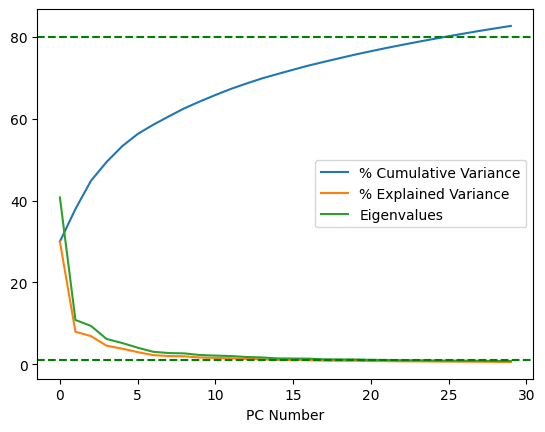

In [43]:
sum_explained_variance = []
for i in range(len(explained_variance)):
    sum_explained_variance.append(sum(explained_variance[:i+1])*100)
plt.plot(sum_explained_variance,label = '% Cumulative Variance')
plt.plot(explained_variance*100,label = '% Explained Variance')
plt.plot(eigenvalues,label = 'Eigenvalues')
plt.axhline(y=80,linestyle='dashed',c = 'green')
plt.axhline(y=1,linestyle='dashed',c = 'green')
plt.xlabel('PC Number')
plt.legend();

<a href="#Flight-data" style="text-decoration: none;">
    <button style="padding:10px; font-size:15px;">Back to Top</button>
</a>

## PC

<a href="#Scatter" style="text-decoration: none;">
    <button style="padding:10px; font-size:15px;">Scatter</button>
</a>

<a href="#Boxplot" style="text-decoration: none;">
    <button style="padding:10px; font-size:15px;">Boxplot</button>
</a>

<a href="#PCA-Map-View" style="text-decoration: none;">
    <button style="padding:10px; font-size:15px;">Map View</button>
</a>

<a href="#Flight-data" style="text-decoration: none;">
    <button style="padding:10px; font-size:15px;">Back to Top</button>
</a>

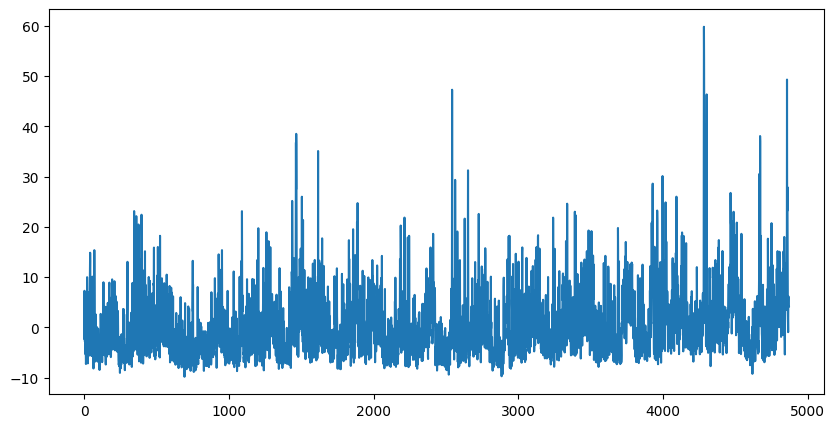

In [44]:
plt.figure(figsize=(10,5))

plt.plot(pca_df[0])

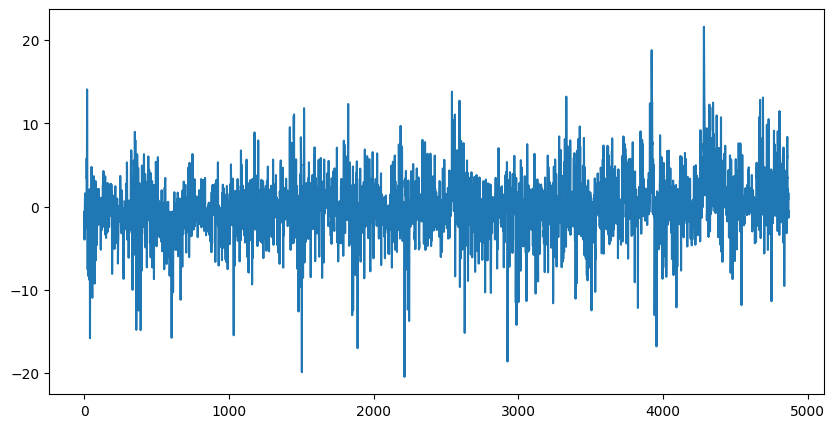

In [45]:
plt.figure(figsize=(10,5))

plt.plot(pca_df[1])


In [46]:
temp = pca_df.copy()

In [47]:
temp

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,-2.210313,-0.683128,1.209149,0.741712,0.349108,1.531934,-0.440146,1.597781,-0.337346,0.165049,...,-0.655567,0.782950,-1.057291,0.014025,0.357200,-0.469380,0.223865,0.579851,-0.913252,-0.326730
1,4.666468,-1.089737,-1.397503,2.184368,-1.666554,-0.827497,-1.479873,0.970029,-0.890683,0.992250,...,-1.069098,0.122048,-0.889266,0.327162,-0.492568,0.715257,0.337385,1.341231,-1.030589,-0.060835
2,7.296955,-3.957857,-2.697423,0.940441,-1.009541,-0.752922,-2.618785,2.563124,-1.728355,-0.207333,...,-1.313368,-0.737014,-1.291855,0.793969,-0.029441,0.636643,-0.169949,1.133689,0.661475,0.183680
3,1.282399,-0.602681,-0.156426,0.644340,-1.148123,-0.220956,-1.267336,1.923612,0.489181,-1.019485,...,-1.495259,0.683949,-0.307114,0.106344,0.998884,0.220727,-0.593869,1.582829,-1.711222,0.490268
4,-1.925256,-0.302181,0.602777,-0.455017,-2.001319,0.567451,-0.291322,1.216773,0.279432,-0.641546,...,-1.363021,1.311690,0.669550,0.039547,0.419865,-0.065293,-0.150489,0.539179,-0.907877,-0.067976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4864,-0.928415,0.761757,-2.459650,-0.689128,0.816792,0.754510,-0.428036,-0.525693,0.175424,0.455782,...,-0.946241,0.193142,-1.071093,0.903012,-0.003987,-0.106496,-0.405273,-0.110111,-0.417446,-0.190925
4865,4.937723,1.635519,-5.085908,-1.403197,0.800335,1.540921,-1.358492,-0.567852,1.921266,0.479950,...,-0.763554,-0.203170,-0.611676,0.713794,-0.150984,0.241067,-0.356340,-0.535263,-1.058066,0.106908
4866,6.188043,0.135560,-5.793889,-1.451424,0.051831,1.838126,-0.385079,0.112809,3.288081,0.783154,...,-1.336396,-0.593181,0.107063,-0.683135,0.329628,0.168150,-1.114209,-0.128695,-1.627198,0.494138
4867,4.065097,-1.330488,-4.154635,-1.577954,0.131555,-0.306596,0.562212,-0.376020,2.171173,0.036795,...,-0.751686,-0.376864,-0.628653,-0.438969,-0.235339,-0.692694,-0.684677,0.042922,-1.232202,-0.486462


## PCA Map View

<a href="#PC1" style="text-decoration: none;">
    <button style="padding:10px; font-size:15px;">PC1</button>
</a>

<a href="#PC2" style="text-decoration: none;">
    <button style="padding:10px; font-size:15px;">PC2</button>
</a>

<a href="#PC3" style="text-decoration: none;">
    <button style="padding:10px; font-size:15px;">PC3</button>
</a>

<a href="#PC4" style="text-decoration: none;">
    <button style="padding:10px; font-size:15px;">PC4</button>
</a>

## PC1

In [48]:
airportLocation = pd.read_csv('airportLocation.csv').drop('Unnamed: 0',axis=1)
huborzone_temp = np.array([' EWR', 'ZFW', 'ZAB', 'ZMP', ' TPA', 'ZBW', 'ZSE', ' PHL', 'ZAN',
       ' DCA', ' IAH', ' CLT', ' ATL', 'ZDV', ' ORD', 'ZOB', ' MIA',
       ' AUS', ' MDW', ' LAX', ' LAS', 'ZOA', 'ZLC', 'ZME', 'ZID', 'ZKC',
       ' MCO', ' BWI', ' IAD', ' SAN', ' FLL', 'ZHN', ' JFK', ' LGA'])

In [49]:
hubAirportLocation = airportLocation[airportLocation['LOCID'].isin(L)]
order = list(huborzone_temp)
hubAirportLocation['huborzone'] = pd.Categorical(hubAirportLocation['huborzone'], categories=order, ordered=True)
hubAirportLocation = hubAirportLocation.sort_values(by='huborzone')

In [50]:
loadings_df

,0,1,2,3,4,5,6,7,8,9,...,126,127,128,129,130,131,132,133,134,135
0,0.092383,0.104689,0.112953,0.051986,0.059409,0.076160,0.080798,0.023477,0.085678,0.109188,...,0.038953,0.020030,0.083054,0.102088,0.103127,0.057855,0.093413,0.097153,0.102152,0.051416
1,-0.152115,-0.114924,-0.106248,-0.098381,0.060572,0.110663,0.111065,0.089647,0.075546,0.142627,...,0.082367,0.054002,-0.151760,-0.124832,-0.103481,-0.110062,-0.160157,-0.126666,-0.119058,-0.116255
2,0.119690,-0.068664,-0.047655,-0.070296,0.111233,-0.019546,-0.020576,-0.005184,0.175054,-0.038046,...,-0.014094,-0.019631,0.121867,-0.050535,-0.041629,-0.070633,0.116000,-0.063241,-0.060484,-0.062219
3,0.050681,0.071958,0.084639,0.053578,-0.160832,-0.174587,-0.166378,-0.160765,-0.044932,0.011267,...,0.068108,0.019598,0.069042,0.095045,0.107333,0.054633,0.057450,0.066804,0.071379,0.068440
4,0.018659,-0.051011,-0.034631,-0.024168,0.123497,0.114722,0.119038,0.117098,0.077551,0.031768,...,0.076111,0.053827,0.047149,0.006233,0.002979,-0.028285,0.018018,-0.041696,-0.043142,-0.040856
5,-0.081602,-0.137601,-0.110072,-0.154660,-0.157484,-0.185628,-0.178829,-0.198353,-0.034554,-0.067228,...,0.073396,0.055442,-0.059331,-0.103794,-0.089628,-0.138136,-0.089913,-0.133658,-0.115635,-0.163562
6,0.042530,-0.022700,-0.048159,0.125204,-0.020448,-0.026271,-0.057472,0.089699,-0.005327,0.060800,...,0.069780,0.197022,0.032655,0.012940,-0.036592,0.078270,0.032376,0.010027,-0.019074,0.074935
7,-0.027648,0.040036,0.030733,0.073176,0.023722,0.024850,0.022002,0.051471,0.040539,-0.050724,...,0.223011,0.146493,-0.021350,0.017892,0.018506,0.058737,-0.020038,0.039990,0.030078,0.069489
8,-0.063988,-0.024258,-0.055264,-0.020006,-0.015304,-0.011841,-0.020890,-0.011369,-0.035338,-0.062609,...,-0.049765,-0.011021,-0.071398,-0.067768,-0.090661,-0.056480,-0.050917,-0.018285,-0.055385,0.010753
9,0.011983,-0.011021,0.004801,-0.032412,-0.034290,-0.032969,-0.024942,-0.053087,-0.019305,0.082309,...,-0.185686,-0.207294,0.016324,-0.015729,-0.006592,-0.037563,0.012600,-0.016961,-0.014391,-0.037352


In [51]:
list1 = []
list2 = []
list3 = []
list4 = []
for i in range(34):
    list1.append(loadings_df.loc[0][4*i])
    list2.append(loadings_df.loc[0][4*i+1])
    list3.append(loadings_df.loc[0][4*i+2])
    list4.append(loadings_df.loc[0][4*i+3])
hubAirportLocation_temp = hubAirportLocation.copy()
hubAirportLocation_temp['PC1'] = list1
hubAirportLocation_temp['PC2'] = list2
hubAirportLocation_temp['PC3'] = list3
hubAirportLocation_temp['PC4'] = list4
hubAirportLocation_temp = hubAirportLocation_temp.sort_values('LONGITUDE')[['PC1','PC2','PC3','PC4']].T
hubAirportLocation_temp

,203,23,423,421,257,409,255,364,432,124,...,303,163,217,121,80,363,155,267,240,66
PC1,0.024042,0.024072,0.062349,0.058195,0.081672,0.069682,0.081961,0.085678,0.067757,0.059743,...,0.063420,0.071190,0.092805,0.097558,0.082214,0.087450,0.092383,0.093413,0.083054,0.086091
PC2,0.040967,0.019927,0.063852,0.088679,0.098085,0.099559,0.088432,0.109188,0.092530,0.090052,...,0.109086,0.116824,0.133581,0.126719,0.121383,0.108751,0.104689,0.097153,0.102088,0.119210
PC3,0.038953,0.016482,0.069168,0.076886,0.090200,0.085769,0.090753,0.105845,0.084976,0.092442,...,0.099984,0.111432,0.125954,0.121788,0.119234,0.112375,0.112953,0.102152,0.103127,0.115729
PC4,0.020030,-0.014482,0.011795,0.001466,0.019537,0.012748,0.023334,0.019252,0.005383,0.024204,...,0.036446,0.041087,0.057523,0.057141,0.045089,0.037186,0.051986,0.051416,0.057855,0.055734


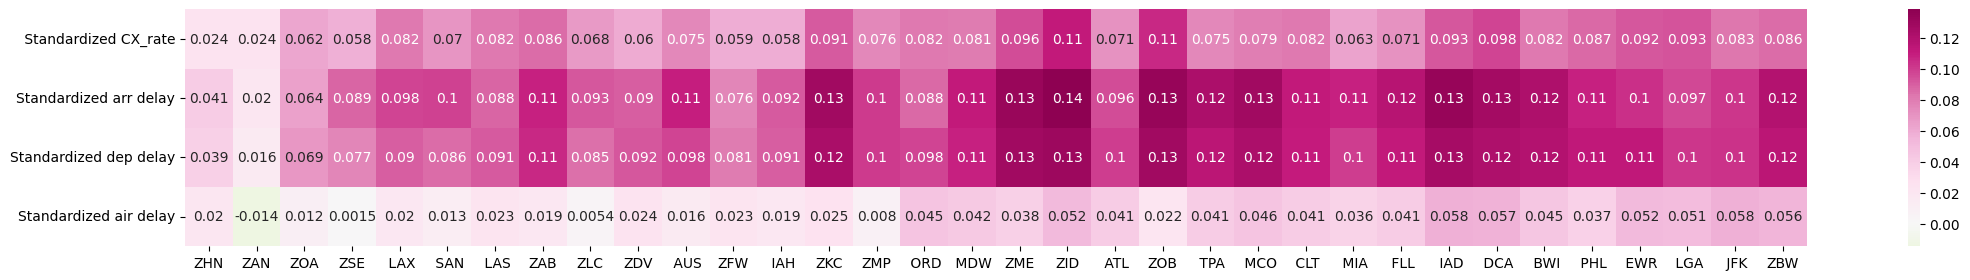

In [52]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
plt.figure(figsize=(34/1.3, 4/1.3))
sns.heatmap(hubAirportLocation_temp, annot=True, fmt=".2",cmap='PiYG_r', center=0,cbar=True,yticklabels = [' Standardized CX_rate','Standardized arr delay','Standardized dep delay','Standardized air delay'],xticklabels = hubAirportLocation.sort_values('LONGITUDE')['huborzone']);

## PC2

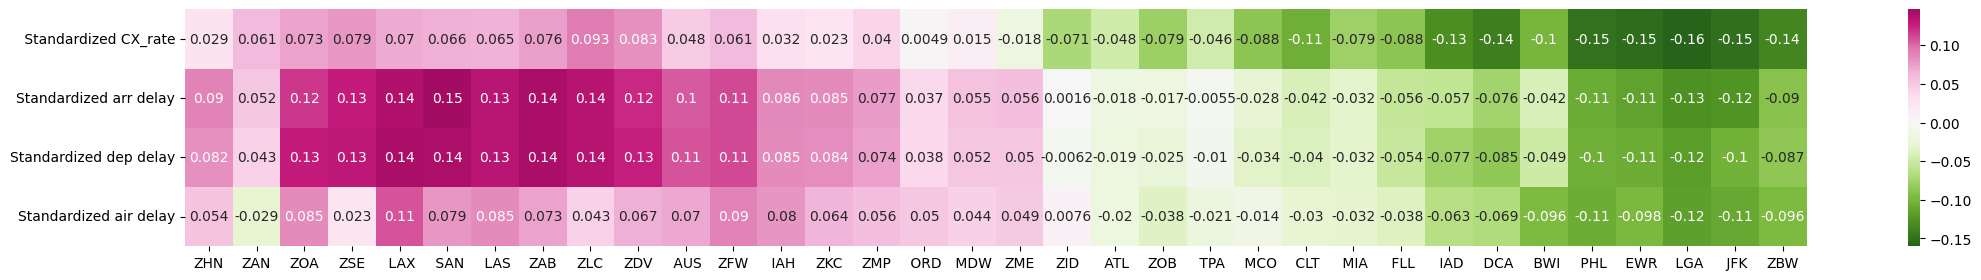

In [53]:
list1 = []
list2 = []
list3 = []
list4 = []
for i in range(34):
    list1.append(loadings_df.loc[1][4*i])
    list2.append(loadings_df.loc[1][4*i+1])
    list3.append(loadings_df.loc[1][4*i+2])
    list4.append(loadings_df.loc[1][4*i+3])
hubAirportLocation_temp = hubAirportLocation.copy()
hubAirportLocation_temp['PC1'] = list1
hubAirportLocation_temp['PC2'] = list2
hubAirportLocation_temp['PC3'] = list3
hubAirportLocation_temp['PC4'] = list4
hubAirportLocation_temp = hubAirportLocation_temp.sort_values('LONGITUDE')[['PC1','PC2','PC3','PC4']].T
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
plt.figure(figsize=(34/1.3, 4/1.3))
sns.heatmap(hubAirportLocation_temp, annot=True, fmt=".2",cmap='PiYG_r', center=0,cbar=True,yticklabels = [' Standardized CX_rate','Standardized arr delay','Standardized dep delay','Standardized air delay'],xticklabels = hubAirportLocation.sort_values('LONGITUDE')['huborzone']);

## PC3

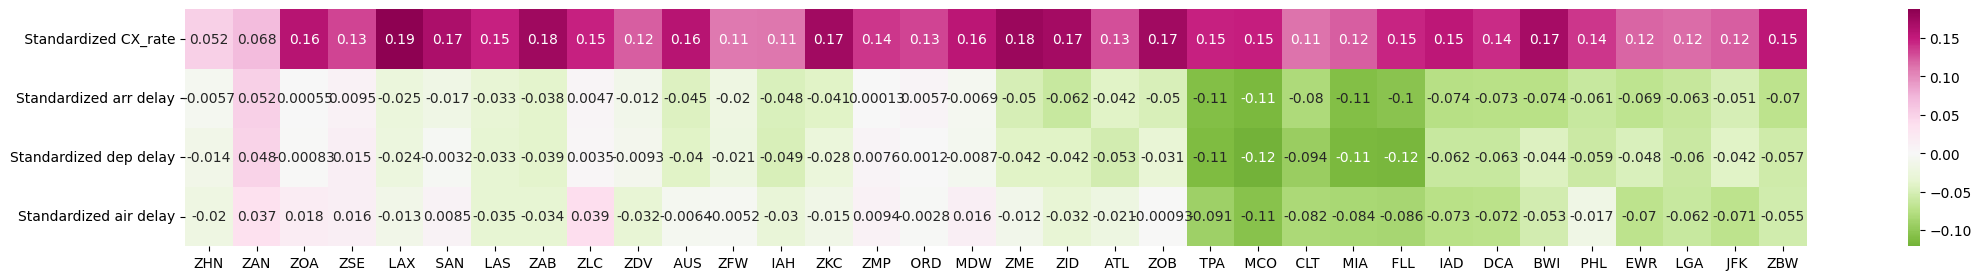

In [54]:
list1 = []
list2 = []
list3 = []
list4 = []
for i in range(34):
    list1.append(loadings_df.loc[2][4*i])
    list2.append(loadings_df.loc[2][4*i+1])
    list3.append(loadings_df.loc[2][4*i+2])
    list4.append(loadings_df.loc[2][4*i+3])
hubAirportLocation_temp = hubAirportLocation.copy()
hubAirportLocation_temp['PC1'] = list1
hubAirportLocation_temp['PC2'] = list2
hubAirportLocation_temp['PC3'] = list3
hubAirportLocation_temp['PC4'] = list4
hubAirportLocation_temp = hubAirportLocation_temp.sort_values('LONGITUDE')[['PC1','PC2','PC3','PC4']].T
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
plt.figure(figsize=(34/1.3, 4/1.3))
sns.heatmap(hubAirportLocation_temp, annot=True, fmt=".2",cmap='PiYG_r', center=0,cbar=True,yticklabels = [' Standardized CX_rate','Standardized arr delay','Standardized dep delay','Standardized air delay'],xticklabels = hubAirportLocation.sort_values('LONGITUDE')['huborzone']);


## PC4 

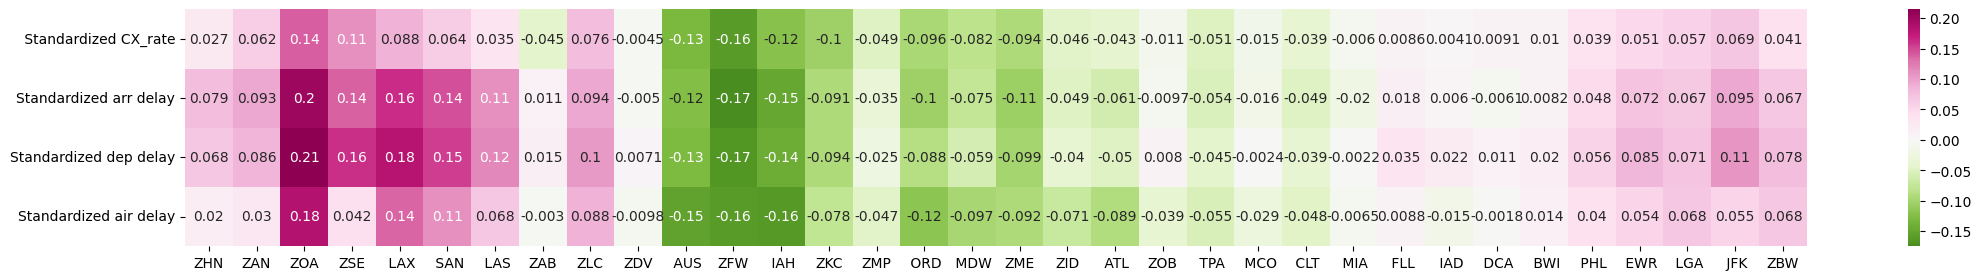

In [55]:
list1 = []
list2 = []
list3 = []
list4 = []
for i in range(34):
    list1.append(loadings_df.loc[3][4*i])
    list2.append(loadings_df.loc[3][4*i+1])
    list3.append(loadings_df.loc[3][4*i+2])
    list4.append(loadings_df.loc[3][4*i+3])
hubAirportLocation_temp = hubAirportLocation.copy()
hubAirportLocation_temp['PC1'] = list1
hubAirportLocation_temp['PC2'] = list2
hubAirportLocation_temp['PC3'] = list3
hubAirportLocation_temp['PC4'] = list4
hubAirportLocation_temp = hubAirportLocation_temp.sort_values('LONGITUDE')[['PC1','PC2','PC3','PC4']].T
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
plt.figure(figsize=(34/1.3, 4/1.3))
sns.heatmap(hubAirportLocation_temp, annot=True, fmt=".2",cmap='PiYG_r', center=0,cbar=True,yticklabels = [' Standardized CX_rate','Standardized arr delay','Standardized dep delay','Standardized air delay'],xticklabels = hubAirportLocation.sort_values('LONGITUDE')['huborzone']);

## PC5

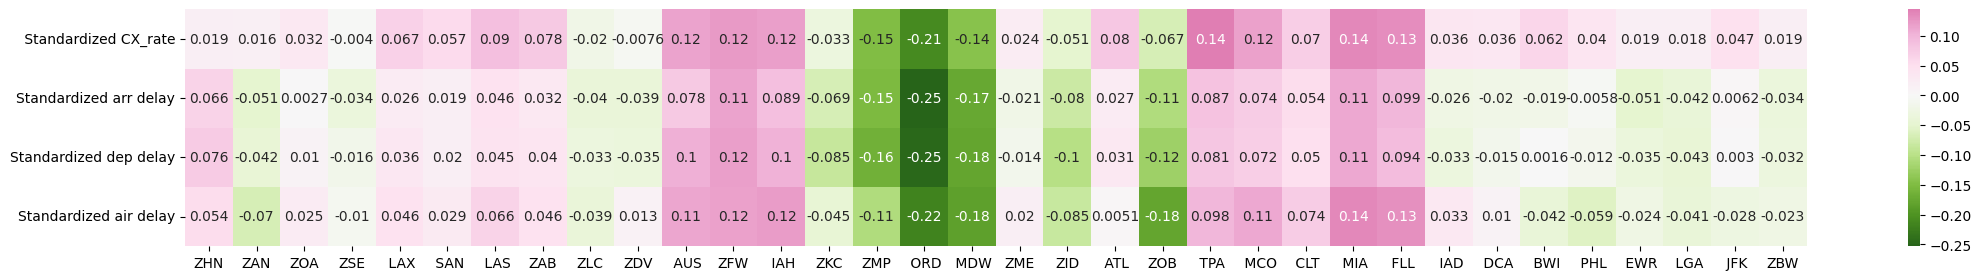

In [56]:
list1 = []
list2 = []
list3 = []
list4 = []
for i in range(34):
    list1.append(loadings_df.loc[4][4*i])
    list2.append(loadings_df.loc[4][4*i+1])
    list3.append(loadings_df.loc[4][4*i+2])
    list4.append(loadings_df.loc[4][4*i+3])
hubAirportLocation_temp = hubAirportLocation.copy()
hubAirportLocation_temp['PC1'] = list1
hubAirportLocation_temp['PC2'] = list2
hubAirportLocation_temp['PC3'] = list3
hubAirportLocation_temp['PC4'] = list4
hubAirportLocation_temp = hubAirportLocation_temp.sort_values('LONGITUDE')[['PC1','PC2','PC3','PC4']].T
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
plt.figure(figsize=(34/1.3, 4/1.3))
sns.heatmap(hubAirportLocation_temp, annot=True, fmt=".2",cmap='PiYG_r', center=0,cbar=True,yticklabels = [' Standardized CX_rate','Standardized arr delay','Standardized dep delay','Standardized air delay'],xticklabels = hubAirportLocation.sort_values('LONGITUDE')['huborzone']);

<a href="#Flight-data" style="text-decoration: none;">
    <button style="padding:10px; font-size:15px;">Back to Top</button>
</a>

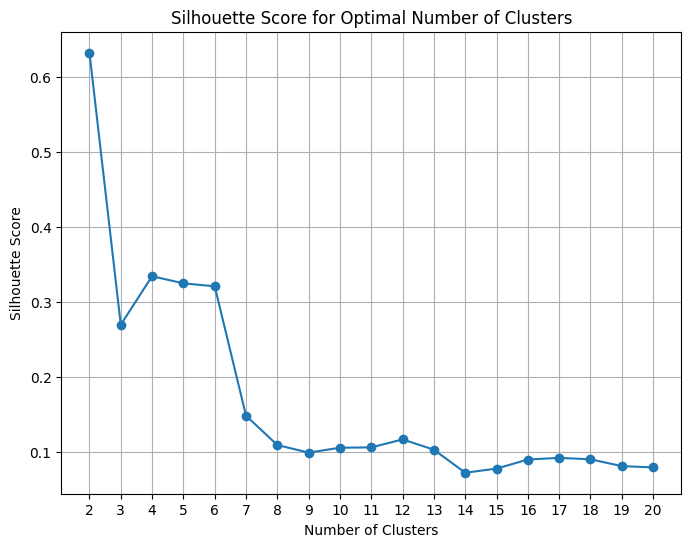

In [57]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Generate synthetic data
#X, _ = make_blobs(n_samples=300, centers=5, cluster_std=0.60, random_state=0)

silhouette_scores = []

# Test KMeans with different numbers of clusters
for k in range(2, 21):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_df[:24])
    labels = kmeans.labels_
    score = silhouette_score(pca_df[:24], labels)
    silhouette_scores.append(score)

# Plot the silhouette scores for different numbers of clusters
plt.figure(figsize=(8, 6))
plt.plot(range(2, 21), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(range(2,21))
plt.title('Silhouette Score for Optimal Number of Clusters')
plt.grid(True)
plt.show()

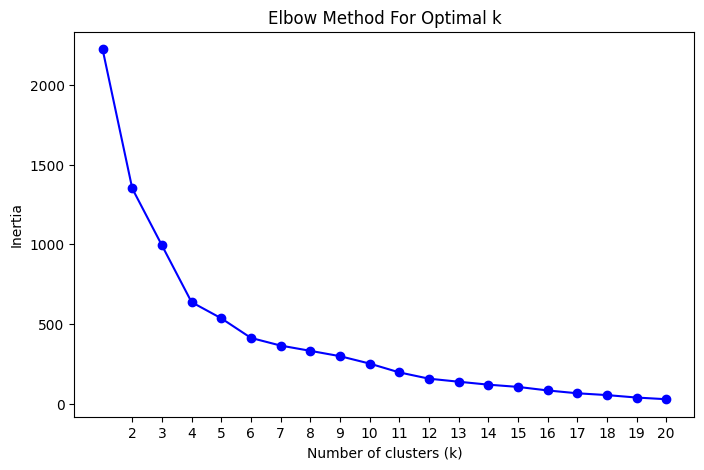

In [58]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Generate sample data
X = pca_df[0:24]

# Elbow method
inertia = []
K = range(1, 21)  # Number of clusters to try
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plotting the elbow plot
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.xticks(range(2,21))
plt.show()

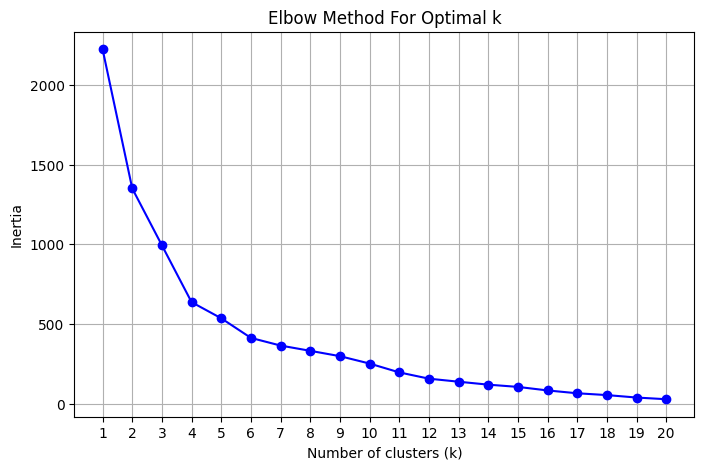

In [59]:
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.grid(True)  # Add a grid to the plot for better visibility
plt.xticks(range(1,21))
plt.show()

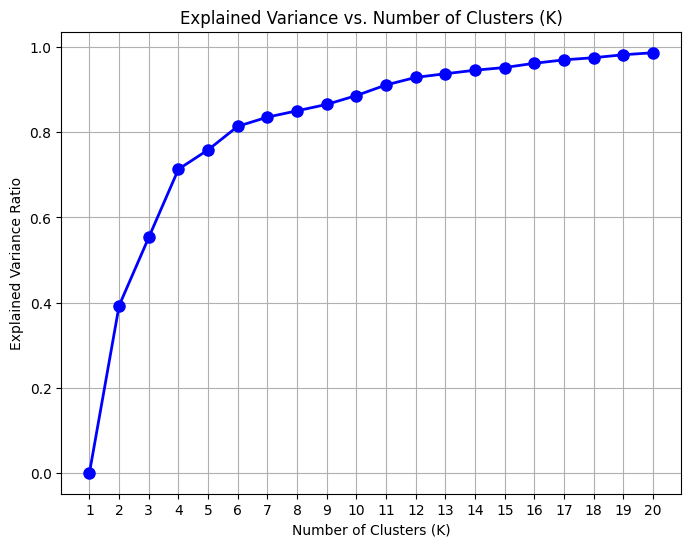

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Assuming X is your 21 by n array of data (21 features and n samples)
# Replace this with your actual data matrix
# X = your_data_array  # Uncomment this line and assign your actual data to X

# Calculate total variance (TV) - variance from the overall mean
overall_mean = np.mean(X, axis=0)
total_variance = np.sum((X - overall_mean) ** 2)
total_variance = np.sum(total_variance)

# Lists to store WCSS and explained variance ratio (EVR)
wcss = []
explained_variance_ratios = []

# Loop over different numbers of clusters (K)
K_range = range(1, 21)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    
    # Inertia (WCSS) for this K
    wcss_value = kmeans.inertia_
    wcss.append(wcss_value)
    
    # Between-Group Variance (BCSS) calculation
    cluster_centroids = kmeans.cluster_centers_
    bcss = sum([len(X[kmeans.labels_ == i]) * np.sum((centroid - overall_mean) ** 2)
                for i, centroid in enumerate(cluster_centroids)])
    
    # Explained variance ratio
    evr = bcss / total_variance
    explained_variance_ratios.append(evr)

# Clear previous plots and create a new figure
plt.figure(figsize=(8, 6))  # Ensures the figure is new and no overlapping plots
plt.plot(K_range, explained_variance_ratios, 'bo-', linewidth=2, markersize=8)  # Single line plot
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance vs. Number of Clusters (K)')
plt.grid(True)  # Add a grid to the plot for better visibility
plt.xticks(range(1,21))
plt.show()


In [45]:
name = ['YYYYMM','DAY','Weekday']
for i in huborzone_temp:
    name.append(i+'CX_rate')
    name.append(i+'arr_delay')
    name.append(i+'dep_delay')
    name.append(i+'air_delay')

In [47]:
#final[name].to_csv('final_CX_rate.csv')